# Preprocesamiento de datos de COVID
### Curso: Machine Learning

**Integrantes:**
- Manuel Laura
- Aydee Carolina Zapana Caillahua
- Absalon Chambilla Condori

**Docente:** Miguel Romilio Aceituno Rojo

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report
)
from sklearn.metrics import roc_curve
from sklearn.preprocessing import OneHotEncoder

In [65]:
import kagglehub, os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_10545264f6b54e0bd995ca4fd9829565"

path = kagglehub.dataset_download("manuellaura/covid-puno")

In [66]:
dfini = pd.read_csv(path + "/covid.csv", low_memory=False, encoding='utf-8')

In [67]:
dfini.head(5)

,id,ano,semana,fecha_not,diresa,red,microred,establecimiento,institucion,clasificacion,...,prueba_rap,resultado_rap,fecha_res_rap,fecha_rap1,muestra_rap1,prueba_rap1,resultado_rap1,fecha_res_rap1,secuenciamiento,asintomatico
0,542,2021,5,09-02-2021,PUNO,PUNO,SIN MICRORED,"HOSP. REG. ""MANUEL NUÑEZ BUTRÓN"" - PUNO",GOBIERNO REGIONAL,DESCARTADO,...,NaN,NaN,NaN,00-00-0000,NaN,NaN,NaN,NaN,NaN,NaN
1,1234,2020,10,07-03-2020,PUNO,SAN ROMAN,SIN MICRORED,"HOSP. ""CARLOS MONGE MEDRANO"" - JULIACA",GOBIERNO REGIONAL,DESCARTADO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1258,2020,10,09-03-2020,PUNO,PUNO,SIN MICRORED,HOSPITAL III DE ESSALUD,ESSALUD,DESCARTADO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1266,2020,10,09-03-2020,PUNO,SAN ROMAN,SIN MICRORED,"HOSP. ""CARLOS MONGE MEDRANO"" - JULIACA",GOBIERNO REGIONAL,DESCARTADO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1292,2021,9,05-03-2021,PUNO,PUNO,METROPOLITANO,C.S. METROPOLITANO PUNO,GOBIERNO REGIONAL,CONFIRMADO,...,SEROLOGIA,NEGATIVO,16-07-2020,00-00-0000,NaN,NaN,NaN,NaN,NaN,NaN


Porcentaje de nulos por columna

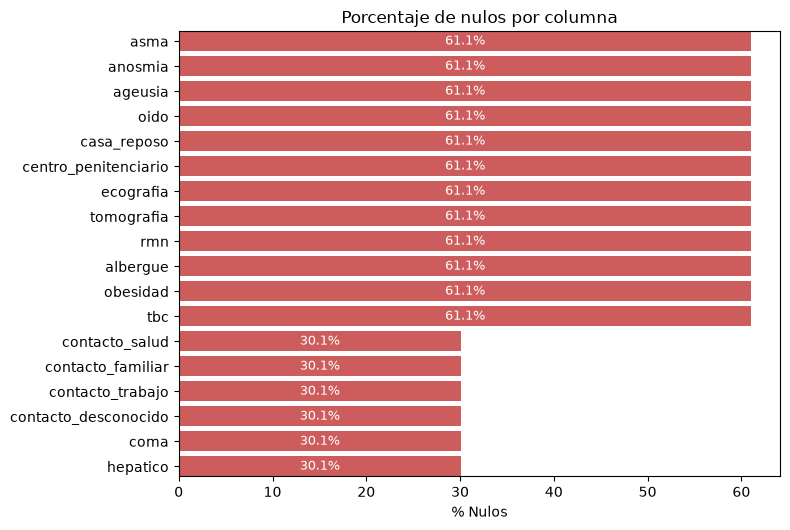

In [68]:

missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(8, max(4, len(missing_pct) * 0.3)))
bars = plt.barh(missing_pct.index, missing_pct.values, color='indianred')
plt.xlabel('% Nulos')
plt.title('Porcentaje de nulos por columna')
plt.gca().invert_yaxis()

plt.margins(y=0)

# add labels centered inside each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width / 2,  # horizontal center of the bar
        bar.get_y() + bar.get_height() / 2,  # vertical center of the bar
        f'{width:.1f}%',
        va='center',
        ha='center',
        fontsize=9,
        color='white'
    )

plt.tight_layout()
plt.show()

## Eliminar columnas NAN >95%

In [69]:
null_pct = dfini.isna().mean()
cols_to_drop = null_pct[null_pct > 0.95].index
dfini = dfini.drop(columns=cols_to_drop)

print(f"Eliminado {len(cols_to_drop)} columnas: {list(cols_to_drop)}")

Eliminado 32 columnas: ['entrada', 'seguro', 'diagnostico_ing', 'otro_hos', 'servicio', 'servicio_otro', 'lugar_def', 'profesion', 'diresa_trabajo', 'red_trabajo', 'microred_trabajo', 'eess_trabajo', 'departamento_trabajo', 'provincia_trabajo', 'distrito_trabajo', 'ubigeo_trabajo', 'ciudad_2', 'ciudad_3', 'esalud_14', 'contacto_otro', 'entorno_otro', 'departamento_mercado', 'provincia_mercado', 'contacto_mercado', 'mercado_localidad', 'muestra1', 'prueba1', 'resultado1', 'muestra2', 'prueba2', 'resultado2', 'secuenciamiento']


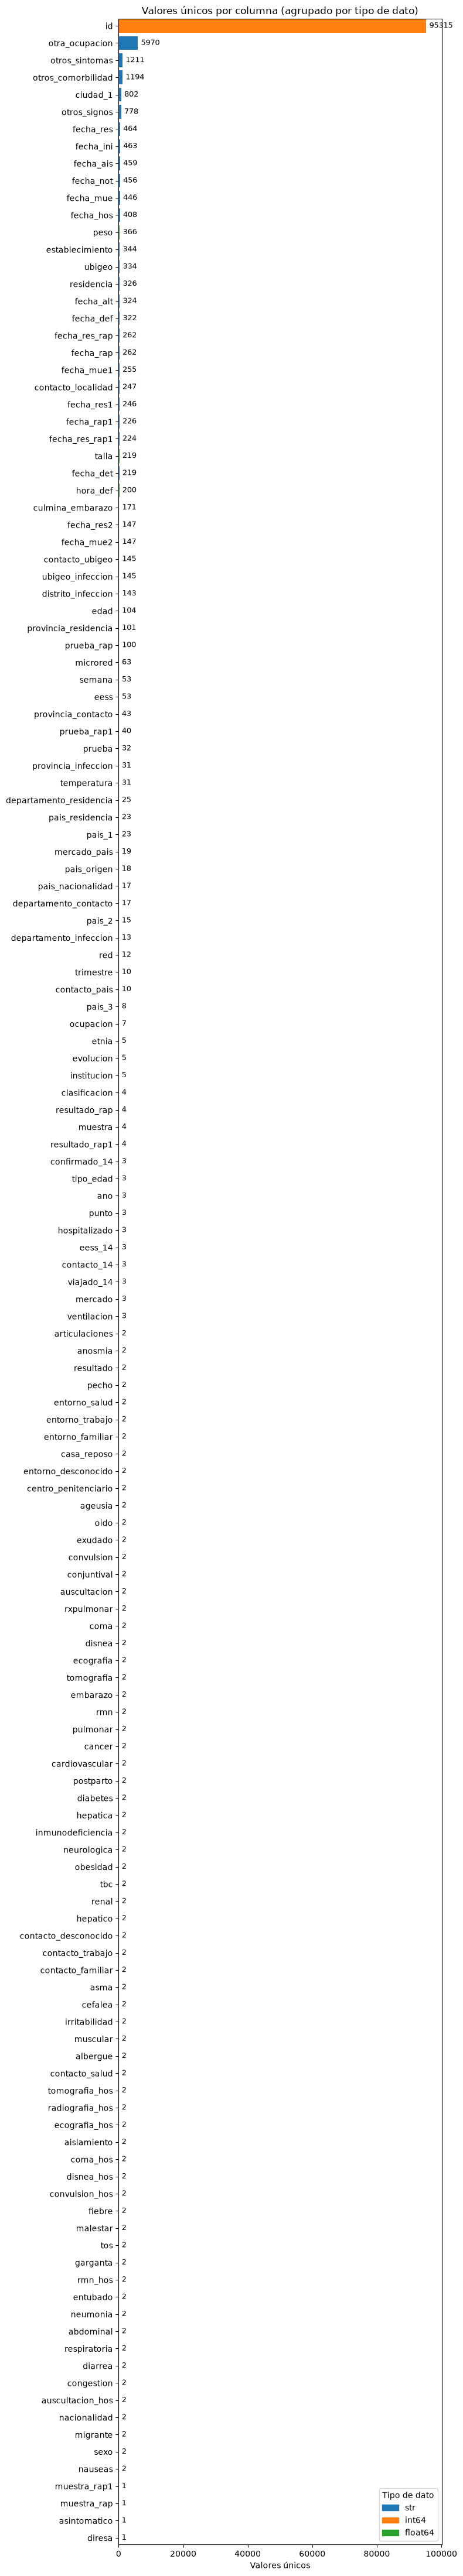

In [70]:
nunique = dfini.nunique().sort_values(ascending=True)
dtypes = dfini[nunique.index].dtypes.astype(str)

# asignar un color a cada tipo de dato
unique_types = dtypes.unique()
colors_map = plt.cm.tab10(range(len(unique_types)))
type_to_color = dict(zip(unique_types, colors_map))
bar_colors = dtypes.map(type_to_color)

plt.figure(figsize=(8, max(4, len(nunique) * 0.3)))
bars = plt.barh(nunique.index, nunique.values, color=bar_colors)
plt.xlabel('Valores únicos')
plt.title('Valores únicos por columna (agrupado por tipo de dato)')

plt.margins(y=0)

# etiquetas con el valor de nunique
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (nunique.max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)}',
        va='center',
        fontsize=9
    )

# leyenda de tipos de dato
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=type_to_color[t]) for t in unique_types]
plt.legend(legend_handles, unique_types, title='Tipo de dato', loc='lower right')

plt.tight_layout()
plt.show()

In [71]:
dfini = dfini.drop(columns=['id'])

In [72]:
categoricas = dfini.select_dtypes(include=["object", "str"]).columns.tolist()
categoricas

['fecha_not',
 'diresa',
 'red',
 'microred',
 'establecimiento',
 'institucion',
 'clasificacion',
 'punto',
 'fecha_det',
 'tipo_edad',
 'sexo',
 'nacionalidad',
 'pais_nacionalidad',
 'migrante',
 'pais_origen',
 'pais_residencia',
 'departamento_residencia',
 'provincia_residencia',
 'residencia',
 'ubigeo',
 'etnia',
 'fecha_ini',
 'departamento_infeccion',
 'provincia_infeccion',
 'distrito_infeccion',
 'ubigeo_infeccion',
 'hospitalizado',
 'fecha_hos',
 'eess',
 'aislamiento',
 'fecha_ais',
 'ventilacion',
 'entubado',
 'neumonia',
 'evolucion',
 'fecha_alt',
 'fecha_def',
 'otros_sintomas',
 'otros_signos',
 'otros_comorbilidad',
 'culmina_embarazo',
 'ocupacion',
 'otra_ocupacion',
 'viajado_14',
 'pais_1',
 'ciudad_1',
 'pais_2',
 'pais_3',
 'eess_14',
 'contacto_14',
 'confirmado_14',
 'contacto_pais',
 'departamento_contacto',
 'provincia_contacto',
 'contacto_ubigeo',
 'contacto_localidad',
 'mercado',
 'mercado_pais',
 'fecha_mue',
 'muestra',
 'prueba',
 'resultado',
 '

In [73]:
dfini['clasificacion'].value_counts()

clasificacion
CONFIRMADO    51293
DESCARTADO    34325
SOSPECHOSO     9611
PROBABLE         82
Name: count, dtype: int64

In [74]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


def preprocesar_datos(df, target="hospitalizado"):
    data = df.copy()

    # =========================================================
    # 1. TARGET
    # =========================================================

    data = data.dropna(subset=[target])

    data[target] = (
        data[target]
        .astype(str)
        .str.strip()
        .str.upper()
        .map({
            "NO": 0,
            "SI": 1
        })
    )

    # eliminar valores que no pudieron convertirse
    data = data.dropna(subset=[target])
    data[target] = data[target].astype(int)

    columnas_excluir = [
        # Fechas
        "fecha_not",
        "fecha_det",
        "fecha_ini",
        "fecha_mue",
        "fecha_res",
        "fecha_mue1",
        "fecha_res1",
        "fecha_mue2",
        "fecha_res2",
        "fecha_rap",
        "fecha_rap1",
        "fecha_res_rap",
        "fecha_res_rap1",
        "fecha_hos",
        "fecha_ais",
        "fecha_alt",
        "fecha_def",
        "hora_def",
        "diresa",
        "red",
        "microred",
        "otra_ocupacion",
        "establecimiento",
        "otros_sintomas",
        "otros_comorbilidad",
        # Variables con posible leakage
        "eess",
        "aislamiento",
        "convulsion_hos",
        "disnea_hos",
        "coma_hos",
        "auscultacion_hos",
        "radiografia_hos",
        "ecografia_hos",
        "tomografia_hos",
        "rmn_hos",
        "ventilacion",
        "entubado",
        "neumonia",
        "evolucion",
        "prueba_rap1",
        "resultado_rap1",
        "otros_signos",
        "ubigeo",
        "hora_def",
        "ciudad_1"
    ]

    data = data.drop(
        columns=[col for col in columnas_excluir if col in data.columns],
        errors="ignore"
    )

    # =========================================================
    # 3. LIMPIEZA DE TEXTO
    # =========================================================

    if "ciudad_1" in data.columns:
        data["ciudad_1"] = (
            data["ciudad_1"]
            .fillna("DESCONOCIDO")
            .astype(str)
            .str.strip()
            .str.upper()
        )
        # Nota: se elimina el replace() inútil (JULIACA -> JULIACA).
        # Si hay variantes reales a corregir, agregarlas aquí, ej:
        # data["ciudad_1"] = data["ciudad_1"].replace({"HULIACA": "JULIACA"})

    # =========================================================
    # 4. NORMALIZAR PRUEBAS RÁPIDAS
    # =========================================================

    colsrp = [
        col for col in ["prueba_rap", "prueba_rap1"]
        if col in data.columns
    ]

    for col in colsrp:
        data[col] = (
            data[col]
            .fillna("DESCONOCIDO")
            .astype(str)
            .str.strip()
            .str.replace("&nbsp;", " ", regex=False)
            .str.replace(r"[\xa0\u200b\u2007\u202f\s]+", " ", regex=True)
            .str.replace(r"[^\w\s]", "", regex=True)
            .str.upper()
        )

        data[col] = data[col].replace({
            "RAPIDO": "PRUEBA RAPIDA",
            "RPUEBA RAPIDA": "PRUEBA RAPIDA",
            "PRUEBA RAAPIDA": "PRUEBA RAPIDA",
            "RPIDA": "PRUEBA RAPIDA",
            "RAPIDA": "PRUEBA RAPIDA",
            "RAPIDAR": "PRUEBA RAPIDA",
            "PRUEBA  RAPIDA": "PRUEBA RAPIDA",
            "PRUEVA RAPIDA": "PRUEBA RAPIDA",
            "PRUEBA RAPIDA COVID 19": "PRUEBA RAPIDA",
            "PRUEBA RAPIDA COVID19": "PRUEBA RAPIDA",
            "TEST RAPIDO PARA COVID 19": "PRUEBA RAPIDA",
            "PRUEVA RRAPIDA": "PRUEBA RAPIDA",
            "PR COVID 19": "PRUEBA RAPIDA",
            "R": "PRUEBA RAPIDA",
            "PR": "PRUEBA RAPIDA",
            "SEROLOGIA": "SEROLOGICA",
            "SEROLOGICO": "SEROLOGICA",
            "SERELOGICA": "SEROLOGICA",
            "SEROLOGÍA": "SEROLOGICA",
            "PRUEBA SEROLOGICA": "SEROLOGICA",
            "SEROÓGICA": "SEROLOGICA",
            "S": "SEROLOGICA",
            "CEROLOGICA": "SEROLOGICA",
            "SEROLÓGICO": "SEROLOGICA",
            "SEROLIGICA": "SEROLOGICA",
            "SANGRE TOTAL": "PRUEBA RAPIDA SANGRE TOTAL",
            "RAPIDA SANGRE TOTAL": "PRUEBA RAPIDA SANGRE TOTAL",
            "RÁPIDA SANGRE TOTAL": "PRUEBA RAPIDA SANGRE TOTAL",
            "SANGRE": "PRUEBA RAPIDA SANGRE TOTAL",
            "MUESTRA DE SANGRE": "PRUEBA RAPIDA SANGRE TOTAL",
            "SANGREZ TOTAL": "PRUEBA RAPIDA SANGRE TOTAL",
        })

    # =========================================================
    # 5. FECHAS -> convertir a features numéricas y ELIMINAR el datetime original
    # =========================================================

    datecols = ["fecha_rap", "fecha_rap1", "fecha_res_rap", "fecha_res_rap1"]
    datecols = [col for col in datecols if col in data.columns]

    for col in datecols:
        data[col] = pd.to_datetime(data[col], format="%d-%m-%Y", errors="coerce")

    # Ejemplo de feature útil: días entre toma de muestra y resultado
    if "fecha_rap" in data.columns and "fecha_res_rap" in data.columns:
        data["dias_resultado_rap"] = (
                data["fecha_res_rap"] - data["fecha_rap"]
        ).dt.days
        data["dias_resultado_rap"] = data["dias_resultado_rap"].fillna(
            data["dias_resultado_rap"].median()
        )

    if "fecha_rap1" in data.columns and "fecha_res_rap1" in data.columns:
        data["dias_resultado_rap1"] = (
                data["fecha_res_rap1"] - data["fecha_rap1"]
        ).dt.days
        data["dias_resultado_rap1"] = data["dias_resultado_rap1"].fillna(
            data["dias_resultado_rap1"].median()
        )

    # IMPORTANTE: eliminar las columnas datetime originales, ya que sklearn/XGBoost
    # no aceptan datetime64 directamente y de lo contrario quedarían "colgadas" en el df final.
    data = data.drop(columns=datecols, errors="ignore")

    # =========================================================
    # 6. VARIABLES NUMÉRICAS REALES
    # =========================================================

    numericas = ["edad", "peso", "talla", "temperatura"]
    numericas = [col for col in numericas if col in data.columns]

    for col in numericas:
        data[col] = pd.to_numeric(data[col], errors="coerce")
        data[col] = data[col].fillna(data[col].median())

    # =========================================================
    # 7. VALIDACIÓN DE NUMÉRICAS
    # =========================================================

    if "edad" in data.columns:
        data = data[(data["edad"] >= 0) & (data["edad"] <= 120)]

    if "peso" in data.columns:
        mediana = data["peso"].median()
        data.loc[(data["peso"] <= 0) | (data["peso"] > 300), "peso"] = mediana

    if "talla" in data.columns:
        mediana = data["talla"].median()
        data.loc[(data["talla"] <= 0) | (data["talla"] > 250), "talla"] = mediana

    binarias_nan_a_cero = [
        "anosmia", "ageusia", "oido", "ecografia", "tomografia", "rmn",
        "tbc", "obesidad", "albergue", "asma", "centro_penitenciario",
        "casa_reposo", "hepatico", "coma",
        "contacto_trabajo", "contacto_familiar", "contacto_salud", "contacto_desconocido"
    ]

    binarias_nan_a_cero = [col for col in binarias_nan_a_cero if col in data.columns]

    for col in binarias_nan_a_cero:
        data[col] = pd.to_numeric(data[col], errors="coerce")  # por si vienen como str
        data[col] = data[col].fillna(0)
        data[col] = data[col].clip(0, 1).astype(int)
    # =========================================================
    # 8. CATEGÓRICAS
    # =========================================================

    categoricas = [
        "diresa", "red", "microred", "establecimiento", "institucion",
        "clasificacion", "punto", "tipo_edad", "sexo", "nacionalidad",
        "pais_nacionalidad", "pais_origen", "pais_residencia",
        "departamento_residencia", "provincia_residencia", "residencia",
        "ubigeo", "etnia", "departamento_infeccion", "provincia_infeccion",
        "distrito_infeccion", "ubigeo_infeccion", "otros_sintomas",
        "otros_signos", "otros_comorbilidad", "culmina_embarazo",
        "ocupacion", "otra_ocupacion", "pais_1", "ciudad_1", "pais_2",
        "pais_3", "eess_14", "contacto_pais", "departamento_contacto",
        "provincia_contacto", "contacto_ubigeo", "contacto_localidad",
        "mercado_pais", "muestra", "prueba", "resultado",
        "muestra_rap", "muestra_rap1", "prueba_rap",
        "resultado_rap", "resultado_rap1"  # <- se agregó resultado_rap1
    ]

    categoricas = [col for col in categoricas if col in data.columns]

    # =========================================================
    # 9. VARIABLES BINARIAS
    # =========================================================

    binarias = [
        "migrante", "viajado_14", "contacto_14",
        "confirmado_14", "asintomatico", "mercado"
    ]
    binarias = [col for col in binarias if col in data.columns]

    # =========================================================
    # 10. NORMALIZAR CATEGÓRICAS
    # =========================================================

    for col in categoricas + binarias:
        data[col] = (
            data[col]
            .fillna("DESCONOCIDO")
            .astype(str)
            .str.strip()
            .str.upper()
        )

    # =========================================================
    # 11. LABEL ENCODER (solo binarias SI/NO)
    # =========================================================

    label_encoders = {}

    for col in binarias:
        valores = set(data[col].unique())
        if valores.issubset({"SI", "NO"}):
            le = LabelEncoder()
            data[col] = le.fit_transform(data[col])
            label_encoders[col] = le

    # =========================================================
    # 12. REDUCIR CARDINALIDAD antes del One-Hot
    #     (evita explosión de columnas en variables con miles
    #      de categorías únicas, como ubigeo o establecimiento)
    # =========================================================

    MAX_CATEGORIAS = 30  # umbral ajustable

    onehot_cols = [
        col for col in categoricas + binarias
        if col not in label_encoders
    ]

    for col in onehot_cols:
        frecuencias = data[col].value_counts()
        top_categorias = frecuencias.nlargest(MAX_CATEGORIAS).index
        data[col] = np.where(
            data[col].isin(top_categorias),
            data[col],
            "OTRO"
        )

    # =========================================================
    # 13. ONE-HOT
    # =========================================================

    if onehot_cols:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        encoded = onehot.fit_transform(data[onehot_cols])

        encoded_df = pd.DataFrame(
            encoded,
            columns=onehot.get_feature_names_out(onehot_cols),
            index=data.index
        )

        data = data.drop(columns=onehot_cols)
        data = pd.concat([data, encoded_df], axis=1)

    # =========================================================
    # 14. RESULTADO FINAL
    # =========================================================

    features = [col for col in data.columns if col != target]
    df_procesado = data[features + [target]].copy()

    print(f"DataFrame final: {df_procesado.shape[0]} filas x {df_procesado.shape[1]} columnas")
    print(f"Variables originales: {len(df.columns)}")
    print(f"Variables finales: {len(features)}")

    return df_procesado


In [75]:
def revisar_nan(df):
    """
    Muestra un resumen de valores NaN por columna: cantidad, porcentaje y dtype.
    """
    resumen = pd.DataFrame({
        "n_nan": df.isna().sum(),
        "pct_nan": (df.isna().mean() * 100).round(2),
        "dtype": df.dtypes.astype(str)
    })

    resumen = resumen[resumen["n_nan"] > 0].sort_values("pct_nan", ascending=False)

    print(f"Columnas con al menos un NaN: {len(resumen)} de {df.shape[1]}")
    print(f"Total de filas: {len(df)}")

    return resumen


In [76]:
data = preprocesar_datos(dfini)
df = data

DataFrame final: 95116 filas x 663 columnas
Variables originales: 146
Variables finales: 662


In [52]:
df['hospitalizado'].value_counts()

hospitalizado
0    89239
1     5877
Name: count, dtype: int64

In [78]:
df.info()

<class 'pandas.DataFrame'>
Index: 95116 entries, 0 to 95314
Columns: 663 entries, ano to hospitalizado
dtypes: float64(606), int64(57)
memory usage: 481.8 MB


In [79]:
def mostrar_metricas_clasificacion(y_true, y_pred, y_proba=None, promedio="weighted", modelo=''):
    """
    Muestra métricas de evaluación para modelos de clasificación.

    Parámetros:
    -----------
    y_true : array-like
        Valores reales (ground truth).
    y_pred : array-like
        Valores predichos por el modelo.
    y_proba : array-like, opcional
        Probabilidades predichas (necesario para calcular AUC-ROC).
        Para binaria: shape (n_muestras,) o (n_muestras, 2).
        Para multiclase: shape (n_muestras, n_clases).
    promedio : str
        Estrategia de promedio para métricas multiclase:
        "binary", "micro", "macro" o "weighted".
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    print("=" * 50)
    print("MÉTRICAS DE CLASIFICACIÓN")
    print("=" * 50)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=promedio, zero_division=0)
    rec = recall_score(y_true, y_pred, average=promedio, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=promedio, zero_division=0)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")

    auc = None
    if y_proba is not None:
        y_proba = np.array(y_proba)
        try:
            if y_proba.ndim == 1 or y_proba.shape[1] == 2:
                proba = y_proba if y_proba.ndim == 1 else y_proba[:, 1]
                auc = roc_auc_score(y_true, proba)
            else:
                auc = roc_auc_score(y_true, y_proba, multi_class="ovr", average=promedio)
            print(f"AUC-ROC:   {auc:.4f}")
        except Exception as e:
            print(f"AUC-ROC:   No se pudo calcular ({e})")

    print("\nMatriz de confusión:")
    print(confusion_matrix(y_true, y_pred))

    print("\nReporte de clasificación:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc_roc": auc,
        "modelo": modelo
    }


In [80]:

def plot_roc_auc(y_true, y_score,
                 title="Curva ROC"):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    return auc

In [81]:
df.dtypes

ano                      int64
semana                   int64
edad                     int64
peso                   float64
talla                  float64
                        ...   
asintomatico_SI        float64
mercado_DESCONOCIDO    float64
mercado_NO             float64
mercado_SI             float64
hospitalizado            int64
Length: 663, dtype: object

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

resultados = []
target = 'hospitalizado'
data = df.copy()
data = data.dropna(subset=[target])

# =========================================================
# 5. Train / Test split
# =========================================================
X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



MÉTRICAS DE CLASIFICACIÓN
Accuracy:  0.9589
Precision: 0.9547
Recall:    0.9589
F1-score:  0.9528
AUC-ROC:   0.9369

Matriz de confusión:
[[17739   110]
 [  672   503]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     17849
           1       0.82      0.43      0.56      1175

    accuracy                           0.96     19024
   macro avg       0.89      0.71      0.77     19024
weighted avg       0.95      0.96      0.95     19024



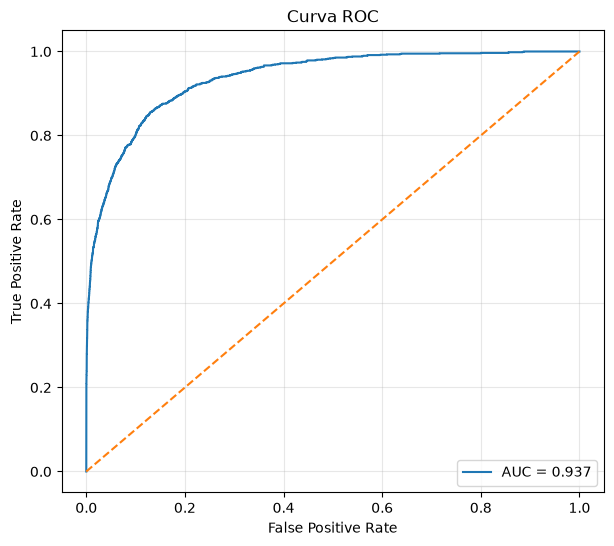

0.936862020996468

In [83]:

modlxgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

modlxgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_predxgb = modlxgb.predict(X_test)
y_probaxgb = modlxgb.predict_proba(X_test)[:, 1]

# =========================================================
# 8. Evaluar con la función de métricas ya creada
# =========================================================
metricas = mostrar_metricas_clasificacion(y_test, y_predxgb, y_proba=y_probaxgb, modelo="XGB")
resultados.append(metricas)

plot_roc_auc(y_test, y_probaxgb)

MÉTRICAS DE CLASIFICACIÓN
Accuracy:  0.9383
Precision: 0.9421
Recall:    0.9383
F1-score:  0.9086
AUC-ROC:   0.8530

Matriz de confusión:
[[17849     0]
 [ 1173     2]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     17849
           1       1.00      0.00      0.00      1175

    accuracy                           0.94     19024
   macro avg       0.97      0.50      0.49     19024
weighted avg       0.94      0.94      0.91     19024



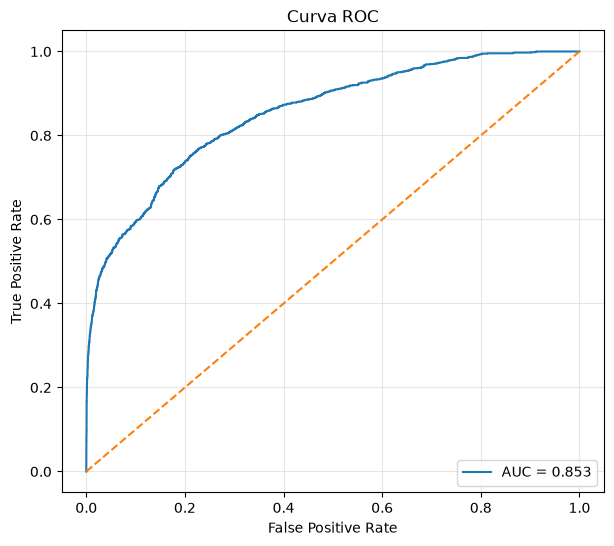

0.8529722506654523

In [84]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

forest.fit(X_train, y_train)

y_pred = forest.predict(X_test)
y_probs = forest.predict_proba(X_test)[:, 1]

resultados.append(mostrar_metricas_clasificacion(y_test, y_pred, y_probs, modelo="Random Forest"))
plot_roc_auc(y_test, y_probs)

MÉTRICAS DE CLASIFICACIÓN
Accuracy:  0.9575
Precision: 0.9535
Recall:    0.9575
F1-score:  0.9499
AUC-ROC:   0.9203

Matriz de confusión:
[[17764    85]
 [  724   451]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     17849
           1       0.84      0.38      0.53      1175

    accuracy                           0.96     19024
   macro avg       0.90      0.69      0.75     19024
weighted avg       0.95      0.96      0.95     19024



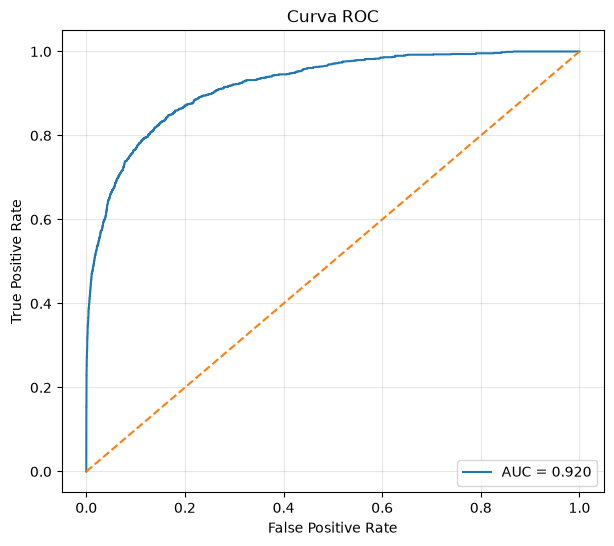

0.9203421134505421

In [85]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting.fit(X_train, y_train)

y_pred = gradient_boosting.predict(X_test)
y_probs = gradient_boosting.predict_proba(X_test)[:, 1]

resultados.append(mostrar_metricas_clasificacion(y_test, y_pred, y_probs, modelo="Gradient Boosting"))
plot_roc_auc(y_test, y_probs)

MÉTRICAS DE CLASIFICACIÓN
Accuracy:  0.9420
Precision: 0.9269
Recall:    0.9420
F1-score:  0.9266
AUC-ROC:   0.7547

Matriz de confusión:
[[17716   133]
 [  971   204]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     17849
           1       0.61      0.17      0.27      1175

    accuracy                           0.94     19024
   macro avg       0.78      0.58      0.62     19024
weighted avg       0.93      0.94      0.93     19024



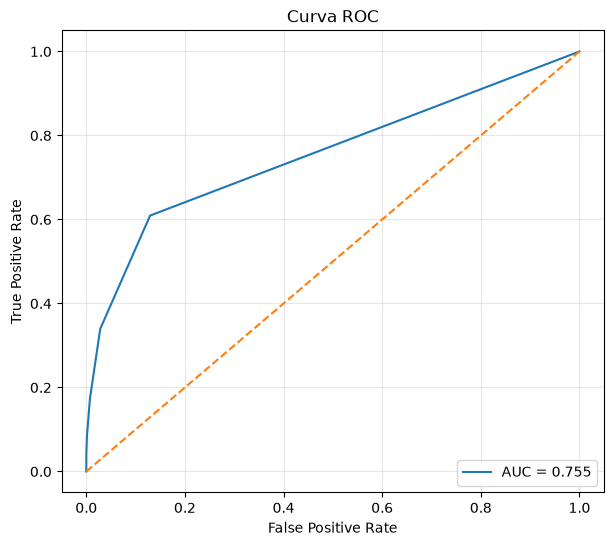

0.7547338369275114

In [86]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
y_probs = knn.predict_proba(X_test)[:, 1]

resultados.append(mostrar_metricas_clasificacion(y_test, y_pred, y_probs, modelo="K-Nearest Neighbors"))
plot_roc_auc(y_test, y_probs)

MÉTRICAS DE CLASIFICACIÓN
Accuracy:  0.9509
Precision: 0.9431
Recall:    0.9509
F1-score:  0.9438
AUC-ROC:   0.8540

Matriz de confusión:
[[17654   195]
 [  740   435]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     17849
           1       0.69      0.37      0.48      1175

    accuracy                           0.95     19024
   macro avg       0.83      0.68      0.73     19024
weighted avg       0.94      0.95      0.94     19024



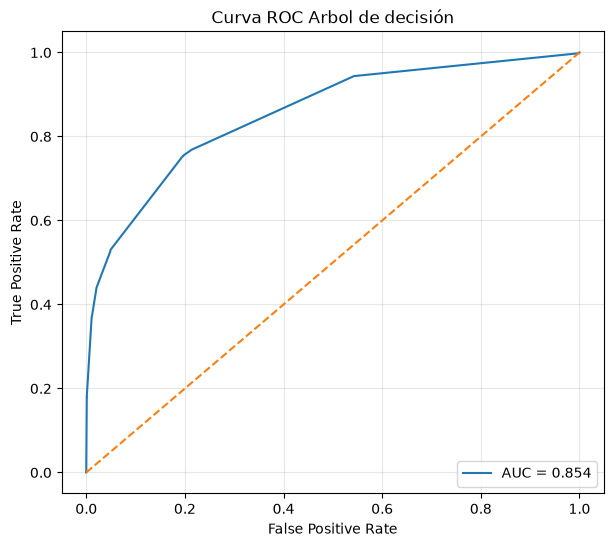

0.8540262223403658

In [87]:
from sklearn.tree import DecisionTreeClassifier

arbol = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

arbol.fit(X_train, y_train)

y_pred = arbol.predict(X_test)
y_probs = arbol.predict_proba(X_test)[:, 1]

resultados.append(mostrar_metricas_clasificacion(y_test, y_pred, y_probs, modelo="Arbol de decisión"))

plot_roc_auc(y_test, y_probs, "Curva ROC Arbol de decisión")

In [88]:
pd.DataFrame(resultados)

,accuracy,precision,recall,f1,auc_roc,modelo
0,0.958894,0.954671,0.958894,0.952752,0.936862,XGB
1,0.938341,0.942143,0.938341,0.908597,0.852972,Random Forest
2,0.957475,0.953464,0.957475,0.949908,0.920342,Gradient Boosting
3,0.941968,0.926872,0.941968,0.926552,0.754734,K-Nearest Neighbors
4,0.950852,0.943137,0.950852,0.943801,0.854026,Arbol de decisión
